Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as any collaborators you worked with:

In [3]:
COLLABORATORS = ""

## To receive credit for this assignment, you must also fill out the [AI Use survey](https://forms.gle/ZhR5k8TdAeN8rj4CA)


---

In [4]:
from __future__ import print_function
%matplotlib inline
%precision 16
import numpy
import matplotlib.pyplot as plt
import time

# HW 7:  Intro to Linear Algebra



# Linear Algebra: Part 1

## Question 1: Matrix Norms and Condition Numbers

Consider the Matrices

$$
    A = \begin{bmatrix} 1 & 1 \\
                        1 & a \\
         \end{bmatrix} \quad\quad
     A^{-1} = \frac{1}{a-1}\begin{bmatrix} a & -1 \\
                        -1 & 1 \\
         \end{bmatrix} 
$$
where $a\in\mathbb{R}$

**(a)** [6] Analytically calculate, as a function of $a$

* the induced $p$-norm $||A||_p$ 
* the $p$ condition number $\kappa_p(A) =||A||_p||A^{-1}||_p$ 

consider  $p=1,2,\inf$

(hint: for a symmetric matrix, the singular values are equal to the absolute value of the eigenvalues of $A$ (sorted from largest to smallest))

For a matrix, as discussed in this class' lecture, 1-norm is the maximum 1-norm of the columns of A, 2-norm is the maximum singular value of A, and $\infty$-norm is the maximum 1-norm of the rows of A. 

$A$ 1-norm: 
The maximum of $2,1+a$ depending on the value of $a$.

$A$ 2-norm: 
The maximum of $1,|a|$, which are the singular values of A.

$A$ $\infty$-norm:
The maximum of $2,1+a$ depending on the value of $a$.

$A^{-1}$ 1-norm: 
1.

$A^{-1}$ 2-norm: 
The maximum of $\left|\frac{a}{a-1}\right|,\left|\frac{1}{a-1}\right|$, which are the singular values of A.

$A^{-1}$ $\infty$-norm:
1.

I think we are assuming that A is invertible, so $a\neq1$. I'm not sure if $a$ is constrained to be positive or negative. Its value dictates what the $p$-norms will be.

$\kappa_1(A)$:
Depending on the value of $a$, this is 2 or $1-a$.

$\kappa_2(A)$:
Depending on the value of $a$, this is $\left|\frac{a}{a-1}\right|$, $\left|\frac{1}{a-1}\right|$, $\left|\frac{a^2}{a-1}\right|$, $\left|\frac{a}{a-1}\right|$.

$\kappa_\infty(A)$:
Same as $\kappa_1(A)$.

**(b)** [6] write two short python routine that returns $||A||_p$, and $\kappa_p(A)$ for the matrices in part (a). Again, just consider $p=1,2,\inf$) and raise a ValueError if $p$ is any other value.

In [5]:
def mypnorm(a, p ):
    """
    return ||A||_p for A = [[ 1, 1],
                            [ 1, a]]
                            
    for p=1, 2, or numpy.inf
    
    parameters:
    -----------
    
    a: scalar 
        value of a
    p: scalar
        1, 2 or np.inf
    returns:
    --------
    float of matrix norm
    
    raises:
    --------
    ValueError:  if p is not in [ 1, 2, numpy.inf]
    """
    if p not in [ 1, 2, numpy.inf]:
        raise ValueError(r"p is not 1,2, or $\infty$")
    
    A = numpy.array([[ 1, 1],[ 1, a]])

    if p==1: # Find p-norm of columns
        return numpy.linalg.norm(A,ord=1)
    elif p==2:
        return numpy.linalg.norm(A,ord=2)
    elif p==numpy.inf:
        return numpy.linalg.norm(A,ord=numpy.inf)

    
def mycond(a, p):
    """
    return pth condition number for A = [[ 1, 1],
                            [ 1, a]]
                            
    for p=1, 2, or numpy.inf
    
    parameters:
    -----------
    
    a: scalar 
        value of a
    p: scalar
        1, 2 or np.inf
    returns:
    --------
    float of condition number

    
    raises:
    --------
    ValueError:  if p is not in [ 1, 2, numpy.inf]    
    """
    if p not in [ 1, 2, numpy.inf]:
        raise ValueError(r"p is not 1,2, or $\infty$")
    
    A = numpy.array([[ 1, 1],[ 1, a]])
    Ainv = numpy.linalg.inv(A)

    normA = mypnorm(a=a,p=p)
    normAinv = numpy.linalg.norm(Ainv,ord=p)

    return normA*normAinv

In [6]:
A = lambda a: numpy.array([ [ 1, 1], [1, a]])
aa = numpy.array([ -2, 0, 1.0001, 2])


for p in [ 1, 2, numpy.inf]:
    normp = [ mypnorm(a, p) for a in aa]
    test = [ numpy.linalg.norm(A(a), ord=p) for a in aa]    
    print('||A||_{} = {}'.format(p, normp))
    numpy.testing.assert_allclose(normp,test)
print('Successful Norm test')

for p in [ 1, 2, numpy.inf]:
    condp = [ mycond(a, p) for a in aa]
    test = [ numpy.linalg.cond(A(a), p) for a in aa]    
    print('k(A)_{} = {}'.format(p, condp))
    numpy.testing.assert_allclose(condp,test)
print('Successful condition number test')

# test the exception
try:
    mypnorm(0.,4)
except ValueError as err:
    print('Success: you caught the ValueError')
else:
    assert False, 'whoops, missed the exception'


||A||_1 = [np.float64(3.0), np.float64(2.0), np.float64(2.0000999999999998), np.float64(3.0)]
||A||_2 = [np.float64(2.302775637731995), np.float64(1.618033988749895), np.float64(2.0000500012499995), np.float64(2.618033988749895)]
||A||_inf = [np.float64(3.0), np.float64(2.0), np.float64(2.0000999999999998), np.float64(3.0)]
Successful Norm test
k(A)_1 = [np.float64(3.0), np.float64(4.0), np.float64(40004.0001000044), np.float64(9.0)]
k(A)_2 = [np.float64(1.7675918792439989), np.float64(2.618033988749895), np.float64(40002.00007500565), np.float64(6.854101966249686)]
k(A)_inf = [np.float64(3.0), np.float64(4.0), np.float64(40004.0001000044), np.float64(9.0)]
Successful condition number test
Success: you caught the ValueError


 **(c)** [4] Make a plot comparing $\log(\kappa(A))$ vs $a$ for the different matrix norms over the range $a\in[-15,15]$. (you can check it by plotting `numpy.linalg.cond(A, ord)` as well. As always, make it pretty.

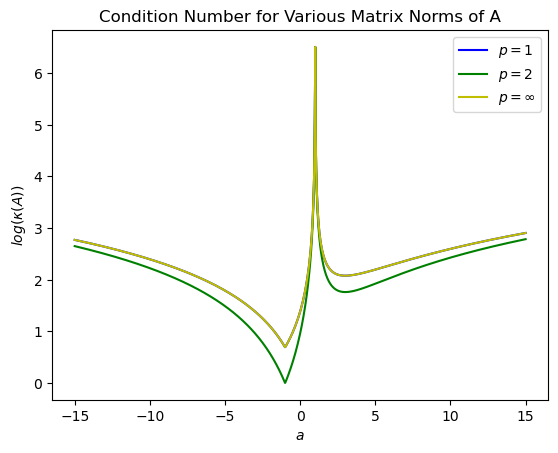

In [25]:
fig,ax=plt.subplots()
aa=numpy.linspace(-15,15,1000)
for i in range(0,len(aa)):
    if aa[i]==1:
        aa.pop(i)
        break
cond_A = numpy.zeros(len(aa))
cond_A_p1 = numpy.zeros(len(aa))
cond_A_p2 = numpy.zeros(len(aa))
cond_A_pinf = numpy.zeros(len(aa))
check = numpy.zeros(len(aa))
for i,a in enumerate(aa):
    cond_A_p1[i]=mycond(a,1)
    cond_A_p2[i]=mycond(a,2)
    cond_A_pinf[i]=mycond(a,numpy.inf)
    # A = lambda a: numpy.array([ [ 1, 1], [1, a]])
    # check[i] = numpy.linalg.cond(A(a),numpy.inf) # check

ax.plot(aa,numpy.log(cond_A_p1),'b',label=r'$p=1$')
ax.plot(aa,numpy.log(cond_A_p2),'g',label=r'$p=2$')
ax.plot(aa,numpy.log(cond_A_pinf),'y',label=r'$p=\infty$')
# ax.plot(aa,numpy.log(check),label='check')

ax.set_title(r'Condition Number for Various Matrix Norms of A')
ax.set_xlabel(r'$a$')
ax.set_ylabel(r'$log(\kappa(A))$')
ax.legend()





**(d)** [4] Given your plot comment on the following:
* What value of $a$ gives the best conditioned matrix.  Why?
* What value of $a$ gives the least well-condition matrix.  Why?
* Does it matter which norm we measure the condition number in?
* What value of $a$ gives the best conditioned matrix for $a>1$
 

The worst condition numbers are the largest and the best are around a condition number of 1. This is because the condition number is the scaling between how much $\mathbf{b}$ changes and as a result how much $\mathbf{x}$ changes under a perturbation in $\mathbf{b}$ for $A\mathbf{x}=\mathbf{b}$. So if the condition number is 1, the perturbation is matched at the same scale, and vice versa.

The worst conditioned matrix seems to occur around $a=1$, which I excluded from the tested values to avoid errors. This is the worst conditioned matrix when $a=1$ because the matrix is singular at this point so it is not invertible and has a zero determinant. 

Since the vertical axis is a log scale, $\kappa=1$ occurs when the log scale hits zero. So around $a=-1$ would be where the matrix is best conditioned. This happens at $a=-1$ because its columns are orthogonal when $a=-1$ and orthogonal matrices always are the best conditioned as they have the easiest least squares solution (there may be a better way to analyze this).

It doesn't seem to matter which norm we use to analyze this with because the trend is apparent for which characteristics we are trying to pick out (best and worst condition numbers). However, it seems that the infinity norm doesn't show the orthogonal matrix as being the global best conditioned, which may provide issues in other cases.

$a\approx2.5$ gives best conditioned matrix for $a>1$ because $A$ must be closest to orthogonal at that point for $a>1$.


## Question 2: Conditioning and LU factorization

Consider the two identical linear problems $A\mathbf{x}=\bf{b}$

$$
    \begin{bmatrix} \epsilon & 1 \\ 1 & 1 \\ \end{bmatrix}\mathbf{x}=\begin{bmatrix} 1\\ 2\end{bmatrix} \quad\quad
     \begin{bmatrix} 1 & 1 \\\epsilon & 1 \\ \end{bmatrix}\mathbf{x}=\begin{bmatrix} 2\\ 1\end{bmatrix} 
$$
where $\epsilon \ll \epsilon_{mach}$

**(a)**  [6 pts] Find the 1 condition number of both matrices. Are they the same?  Are these matrices well conditioned? Check your answer using numpy with $\epsilon = 0.1\epsilon_{mach}$

$$\kappa_1(A) =||A||_1||A^{-1}||_1$$

We will differentiate between the two $A$s as $A_r$ and $A_l$ for the matrix on the right and left as given above, respectively.

$$
A^{-1}_l = \frac{1}{\epsilon - 1}\begin{bmatrix} 1 & -1 \\ -1 & \epsilon \end{bmatrix} \\ 
$$

$$
A^{-1}_r = \frac{1}{1-\epsilon}\begin{bmatrix} 1 & -1 \\ -\epsilon & 1 \end{bmatrix} \\ 
$$

For $\epsilon<<1$, the $l_1$ norm of both these matrices is $\frac{2}{1-\epsilon}$. The same will be true of both $A_r$ and $A_l$. Thus, the condition number of both matrices is the same and it is:

$$
\kappa_1(A_r) = \kappa_1(A_l) = \frac{4}{(1-\epsilon)^2}
$$

This condition number will be roughly equal to 4, and thus these matrices are decently well conditioned as the condition number is not too high and is close to 1, which is a perfectly conditioned matrix.

In [1]:
import numpy as np

epsilon_mach = np.finfo(float).eps  # Machine epsilon
epsilon = 0.1 * epsilon_mach

Ar = np.array([[epsilon, 1],[1, 1]])
Al = np.array([[1, 1],[epsilon, 1]])

kappa_Ar = np.linalg.cond(Ar, 1)
kappa_Al = np.linalg.cond(Al, 1)

print(kappa_Ar)
print(kappa_Al)

4.0
4.0


**(b)**  [4 pts] Find the analytic solution to both problems in infinite precision.  Are they the same?

Infinite precision, so we will assume $\epsilon=0$.

$$
    \begin{bmatrix} 0 & 1 \\ 1 & 1 \\ \end{bmatrix}\mathbf{x}=\begin{bmatrix} 1\\ 2\end{bmatrix} \quad\quad
     \begin{bmatrix} 1 & 1 \\0 & 1 \\ \end{bmatrix}\mathbf{x}=\begin{bmatrix} 2\\ 1\end{bmatrix} 
$$

The right equation can be seen by row operations to reduce to:

$$
\begin{bmatrix} 1 & 0 \\0 & 1 \\ \end{bmatrix}\mathbf{x}=\begin{bmatrix} 1\\ 1\end{bmatrix} \\
\mathbf{x_r}=\begin{bmatrix} 1\\ 1\end{bmatrix}
$$

The left equation can be solved by switching rows 1 and 2 and then using the same row operation as the right equation's solution, thus:
$$
\mathbf{x_l}=\begin{bmatrix} 1\\ 1\end{bmatrix} \\
\mathbf{x_l}=\mathbf{x_r}
$$

Thus the solutions to both the problems in this question are the same in infinite precision.

**(c)**  [4 pts] Now solve both problems analytically using the $LU$ decomposition *without pivoting* but applying the rules of floating point math.  Do you get the same answer?  

To do an LU decomposition of A, we want a lower triangular matrix of multipliers and an upper triangular matrix that comes along for the ride.

$$
L=\begin{bmatrix} 1 & 0 \\ L_{mult} & 1 \\ \end{bmatrix} \\ 
U=\begin{bmatrix} u_{11} & u_{12} \\ 0 & u_{22} \\ \end{bmatrix} \\ 
$$

Let's do this out fully for $A_l$. We take the first row of $A_l$:
$$
L_l=\begin{bmatrix} 1 & 0 \\ L_{mult} & 1 \\ \end{bmatrix} \\ 
U_l=\begin{bmatrix} \epsilon & 1 \\ 0 & u_{22} \\ \end{bmatrix} \\ 
$$
and now we notice when we do $LU$, we are keeping row 1 of $U$ the same and adding $l$ times (row 1) to the original $U$. Thus:
$$
L_l=\begin{bmatrix} 1 & 0 \\ \frac{1}{\epsilon} & 1 \\ \end{bmatrix} \\ 
U_l=\begin{bmatrix} \epsilon & 1 \\ 0 & 1-\frac{1}{\epsilon} \\ \end{bmatrix} \\ 
$$

Solving $A\mathbf{x}=LU\mathbf{x}\equiv L\mathbf{y}=\mathbf{b}$:
$$
    \begin{bmatrix} 1 & 0 \\ \frac{1}{\epsilon} & 1 \\ \end{bmatrix}\mathbf{y}=\begin{bmatrix} 1\\ 2\end{bmatrix} \\
    \mathbf{y} = \begin{bmatrix} 1\\ 2-\frac{1}{\epsilon}\end{bmatrix}
$$

and now solving $U\mathbf{x}=\mathbf{y}$:
$$
    \begin{bmatrix} \epsilon & 1 \\ 0 & 1-\frac{1}{\epsilon} \\ \end{bmatrix}
    \mathbf{y}= \begin{bmatrix} 1\\ 2-\frac{1}{\epsilon}\end{bmatrix} \\

    \mathbf{x} = \begin{bmatrix} \frac{1-\frac{2\epsilon-1}{\epsilon-1}}{\epsilon}\\ \frac{2\epsilon-1}{\epsilon-1} \end{bmatrix}
$$

The issue here is with the floating point math. We have a bunch of divide by $\epsilon$s, including in the multiplier $L_l$ matrix. So if $\epsilon$ is less than machine precision, it will get rounded to zero and then a divide-by-zero error will occur. If $\epsilon$ is around machine precision, catastrophic cancellation is likely to occur (all the following arithmitic is highly sensitive to numerical errors).

Let's instead take a look at the $A_r$ equation, and do an LU decomposition on it:
$$
L_r=\begin{bmatrix} 1 & 0 \\ \epsilon & 1 \\ \end{bmatrix} \\ 
U_r=\begin{bmatrix} 1 & 1 \\ 0 & 1-\epsilon \\ \end{bmatrix} \\
$$

Again we will solve for \mathbf{y} and \mathbf{x} in the same manner as with $A_l$ but I will not show all the steps here:

$$
\mathbf{y}= \begin{bmatrix} 1\\ 1-2\epsilon\end{bmatrix} \\
\mathbf{x} = \begin{bmatrix} \frac{1}{1-\epsilon}\\ \frac{1-2\epsilon}{1-\epsilon} \end{bmatrix}
$$

Notice now we do not have the divide-by-epsilon problem we had before. In $\mathbf{x}$, the denominators won't be super small even though there is an $\epsilon$ in them. This version of this question's problem is much more stable than with $A_l$.

Notice also that if we take $\epsilon$ to zero, the $LU$ factorization solution for $A_l$ goes to $\mathbf{x}=\begin{bmatrix} 0\\1 \end{bmatrix}$ which we know from part b of this problem to not be true. Instead, taking this $\epsilon$ to zero limit in the $LU$ factorization of $A_r$, the solution for this version of this problem becomes $\mathbf{x}=\begin{bmatrix} 1\\1 \end{bmatrix}$ which we know from part b of this problem to be the correct answer.

**(d)**  [6 pts] Check your solutions using numpy.  

For each problem 
* Calculate the solution using $L\mathbf{c}=\mathbf{b}$, $U\mathbf{x}=\mathbf{c}$ for each pair of $L,U$ derived above (you can use numpy here with $\epsilon=0.1\epsilon_{mach}$)
* Calculate the 1-condition number for each $L$ and $U$ 

Briefly explain these results


In [12]:
import numpy as np

epsilon_mach = np.finfo(float).eps  # Machine epsilon
eps = 0.1 * epsilon_mach

# left equations
try:
    b_l = np.array([1,2])
    L_l = np.array([[1,0],[1/eps,1]])
    kappa_L_l = np.linalg.cond(L_l, 1)
    U_l = np.array([[eps,1],[0,1-1/eps]])
    kappa_U_l = np.linalg.cond(U_l, 1)
    c_l = np.linalg.solve(L_l,b_l)
    x_l = np.linalg.solve(U_l,c_l)
except Exception as e:

    b_l = 0
    L_l = 0
    kappa_L_l = 0
    U_l = 0
    kappa_U_l = 0
    c_l = 0
    x_l = 0

    # right equations
    b_r = np.array([2,1])
    L_r = np.array([[1,0],[eps,1]])
    kappa_L_r = np.linalg.cond(L_r, 1)
    U_r = np.array([[1,1],[0,1-eps]])
    kappa_U_r = np.linalg.cond(U_r, 1)
    c_r = np.linalg.solve(L_r,b_r)
    x_r = np.linalg.solve(U_r,c_r)

    print('Left Equations Results:')
    print(r'$\mathbf{x_l} = $',x_l)
    print(r'$\kappa_1(L_l) = $',kappa_L_l)
    print(r'$\kappa_1(U_l) = $',kappa_U_l)

    print('Right Equations Results:')
    print(r'$\mathbf{x_r} = $',x_r)
    print(r'$\kappa_1(L_r) = $',kappa_L_r)
    print(r'$\kappa_1(U_r) = $',kappa_U_r)

# right equations
b_r = np.array([2,1])
L_r = np.array([[1,0],[eps,1]])
kappa_L_r = np.linalg.cond(L_r, 1)
U_r = np.array([[1,1],[0,1-eps]])
kappa_U_r = np.linalg.cond(U_r, 1)
c_r = np.linalg.solve(L_r,b_r)
x_r = np.linalg.solve(U_r,c_r)

print('Left Equations Results:')
print(r'$\mathbf{x_l} = $',x_l)
print(r'$\kappa_1(L_l) = $',kappa_L_l)
print(r'$\kappa_1(U_l) = $',kappa_U_l)

print('Right Equations Results:')
print(r'$\mathbf{x_r} = $',x_r)
print(r'$\kappa_1(L_r) = $',kappa_L_r)
print(r'$\kappa_1(U_r) = $',kappa_U_r)

Left Equations Results:
$\mathbf{x_l} = $ [0. 1.]
$\kappa_1(L_l) = $ 2.028240960365167e+33
$\kappa_1(U_l) = $ 2.028240960365167e+33
Right Equations Results:
$\mathbf{x_r} = $ [1. 1.]
$\kappa_1(L_r) = $ 1.0
$\kappa_1(U_r) = $ 4.0


As found in part c of this problem, the left equations are not well conditioned during its $LU$ decomposition. The $LU$ decomposition of the right equations are well-conditioned. This is seen in the extremely large condition numbers for the left equations and small ones (of order 1) for the right. As expected, the $LU$ decomposition with $L$ and $U$ being ill-conditioned results in the wrong answer for this problem - $\mathbf{x_l}$. The well-conditioned $L$ and $U$, however, result in the correct answer for this problem - $\mathbf{x_r}$ - as there aren't any numerical issues with the arithmatic of well-conditioned $L$ and $U$ but there are with the ill-conditioned ones.